# Example for bssunfold package with Mystic

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bssunfold import Detector, RF_LANL
from bssunfold.utils.plotting import plot_comparison
det = Detector(RF_LANL)

## Get effective readings for spectra

In [ ]:
reference_spectrum = pd.read_csv('../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv')
readings = det.get_effective_readings_for_spectra(reference_spectrum[['E_MeV','ISO_ref_Cf252']])
readings

{'3in': 0.33993480011525595,
 '4in': 1.1540267733387468,
 '5in': 1.6949642349997989,
 '6in': 2.414902989013657,
 '8in': 2.506955384471506,
 '9in': 2.5925178363346078,
 '12in': 1.7633955277542266,
 '18in': 0.509007911100528,
 '9inPb': 2.654290882145632,
 '12inPb': 1.9428831470830863,
 '18inPb': 0.5878222748066373}

In [ ]:
results = {
    "mystic[fmin_powell]": det.unfold_mystic(readings, regularization=0.0001, solver = 'fmin_powell'),
}

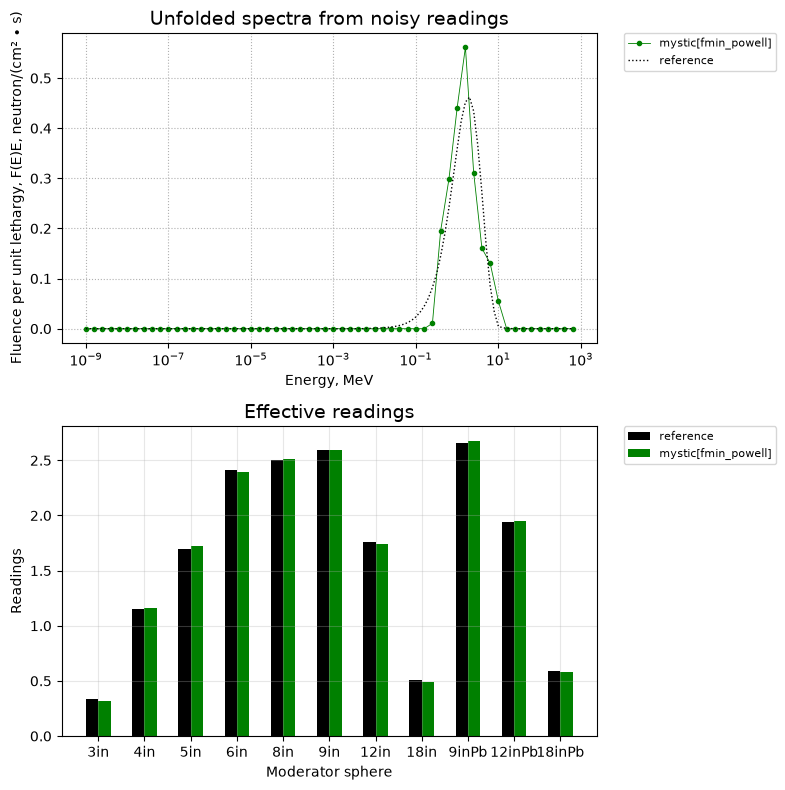

In [ ]:
fig, ax = plot_comparison(
    results=results, 
    readings=readings, 
    reference_spectrum=reference_spectrum[['E_MeV','ISO_ref_Cf252']], 
)